# Importação de Pacotes

In [2]:
#leitura da base de dados
import pandas as pd
from pathlib import Path
import parquet

#modelo preditivo escolhido
import catboost as cb
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

#validação cruzada
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV
import numpy as np

#vetorização
from langchain_experimental.text_splitter import SemanticChunker 
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore

#métricas
import matplotlib
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score, ConfusionMatrixDisplay, classification_report

#pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight

c:\Users\peper\OneDrive\Documentos\PIBIC\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def estimadores(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)

    acuracia = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    roc_auc = roc_auc_score(
        y_test,
        y_proba,
        multi_class='ovr',
        average='weighted'
    )

    ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test)

    print(f"""
        Acurácia: {acuracia:.3f}
        Recall (weighted): {recall:.3f}
        F1-score (weighted): {f1:.3f}
        ROC AUC (ovr): {roc_auc:.3f}
        """)

    print(classification_report(y_test, y_pred))

## Leitura DataFrame

In [4]:
direcao = Path("../..") / "data"
caminho = direcao / "erro_medico_tidy_final.parquet"


df_erro_simples = pd.read_parquet(caminho)

df = df_erro_simples

caminho_vet = direcao / "df_vet.parquet"

df_vet = pd.read_parquet(caminho_vet)

In [5]:
df.head(2)

,n_processo,escopo,data_de_disponibilizacao,decisao,morais_ped,morais_rec,materiais_ped,materiais_rec,classe,assunto,...,tem_hospital,tem_plano_saude,tem_ente_publico,tem_medico_individual,n_adv_autor,n_adv_reu,tem_perito,tem_denuncia_lide,tem_assistente,resumo_caso
0,10169222220248260564,sim,2026-02-24,proced,100000.0,55000.0,-1.0,-1.0,Procedimento Comum Cível,Serviços de Saúde,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,## Identificação do Caso\n- Número do processo...
1,10003518420258260355,sim,2026-02-23,improced,151800.0,0.0,75900.0,0.0,Procedimento Comum Cível,Serviços de Saúde,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,## Identificação do Caso\n- **Número do proces...


In [7]:
df.columns

Index(['n_processo', 'escopo', 'data_de_disponibilizacao', 'decisao',
       'morais_ped', 'morais_rec', 'materiais_ped', 'materiais_rec', 'classe',
       'assunto', 'foro', 'vara', 'juiz', 'data_distribuicao', 'valor_acao',
       'area', 'n_autores', 'n_reus', 'tem_hospital', 'tem_plano_saude',
       'tem_ente_publico', 'tem_medico_individual', 'n_adv_autor', 'n_adv_reu',
       'tem_perito', 'tem_denuncia_lide', 'tem_assistente', 'resumo_caso'],
      dtype='object')

### Preparação Embedding

In [8]:
corpus = df["resumo_caso"].dropna().astype(str).tolist()

In [ ]:
from tqdm.auto import tqdm
import pandas as pd

model_name = "rufimelo/bert-large-portuguese-cased-sts"

model_kwargs = {"device": "cpu"}
encode_kwargs = {"normalize_embeddings": False}

embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs=model_kwargs,
    encode_kwargs=encode_kwargs
)

vector_store = InMemoryVectorStore(embeddings)
text_splitter = SemanticChunker(embeddings, breakpoint_threshold_type="gradient")

# 1) Chunking com progresso
texts = []
for doc in tqdm(corpus, desc="Gerando chunks"):
    texts.extend(text_splitter.create_documents([doc]))

# 2) Indexação em lotes com progresso
document_ids = []
batch_size = 64

for i in tqdm(range(0, len(texts), batch_size), desc="Adicionando ao vector store"):
    batch = texts[i:i + batch_size]
    document_ids.extend(vector_store.add_documents(documents=batch))

# 3) Embeddings com progresso
obj_embed = []
batch_size = 8

for i in tqdm(range(0, len(corpus), batch_size), desc="Calculando embeddings"):
    batch = corpus[i:i + batch_size]
    obj_embed.extend(embeddings.embed_documents(batch))

df_embed = pd.DataFrame(obj_embed)

Invalid model-index. Not loading eval results into CardData.
Gerando chunks:   7%|▋         | 153/2048 [1:42:40<23:31:40, 44.70s/it]

In [ ]:
#axis=1 concatena colunas
df_vet = pd.concat([df, df_embed], axis= 1)

# Aplicação de Pipelines

### CBC

In [6]:
modelo= CatBoostClassifier(auto_class_weights='Balanced')

parametros = {
    'modelo__iterations': [300],
    'modelo__depth': [4, 6, 8],
    'modelo__learning_rate': [0.05, 0.1],
    'modelo__verbose': [0]
}

In [7]:
lista_filtro = ['n_processo', 'escopo', 'data_de_disponibilizacao', 'decisao',
                'morais_ped', 'morais_rec', 'materiais_ped', 'materiais_rec', 
                'classe', 'assunto', 'foro', 'vara', 'juiz', 'data_distribuicao', 
                'area', 'resumo_caso']


X = df_vet.drop(columns=lista_filtro)

y = df_vet["decisao"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=22)


pipeline = Pipeline([
    ('modelo', modelo)
    ])

searchCV_pipeline = RandomizedSearchCV(
    pipeline,
    parametros,
    scoring='f1_macro',
    refit= True,
    cv=5,
    verbose=2
)

searchCV_pipeline.fit(X_train, y_train)

c:\Users\peper\OneDrive\Documentos\PIBIC\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END modelo__depth=4, modelo__iterations=300, modelo__learning_rate=0.05, modelo__verbose=0; total time=  23.6s
[CV] END modelo__depth=4, modelo__iterations=300, modelo__learning_rate=0.05, modelo__verbose=0; total time=  25.1s
[CV] END modelo__depth=4, modelo__iterations=300, modelo__learning_rate=0.05, modelo__verbose=0; total time=  26.1s
[CV] END modelo__depth=4, modelo__iterations=300, modelo__learning_rate=0.05, modelo__verbose=0; total time=  27.9s
[CV] END modelo__depth=4, modelo__iterations=300, modelo__learning_rate=0.05, modelo__verbose=0; total time=  27.3s
[CV] END modelo__depth=4, modelo__iterations=300, modelo__learning_rate=0.1, modelo__verbose=0; total time=  27.4s
[CV] END modelo__depth=4, modelo__iterations=300, modelo__learning_rate=0.1, modelo__verbose=0; total time=  27.5s
[CV] END modelo__depth=4, modelo__iterations=300, modelo__learning_rate=0.1, modelo__verbose=0; total time=  27.5s
[CV] END modelo

,estimator,Pipeline(step...'Balanced'))])
,param_distributions,"{'modelo__depth': [4, 6, ...], 'modelo__iterations': [300], 'modelo__learning_rate': [0.05, 0.1], 'modelo__verbose': [0]}"
,n_iter,10
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan



        Acurácia: 0.607
        Recall (weighted): 0.607
        F1-score (weighted): 0.595
        ROC AUC (ovr): 0.632
        
              precision    recall  f1-score   support

    improced       0.73      0.75      0.74       420
 parc_proced       0.35      0.41      0.37       123
      proced       0.16      0.08      0.11        72

    accuracy                           0.61       615
   macro avg       0.41      0.41      0.41       615
weighted avg       0.59      0.61      0.60       615



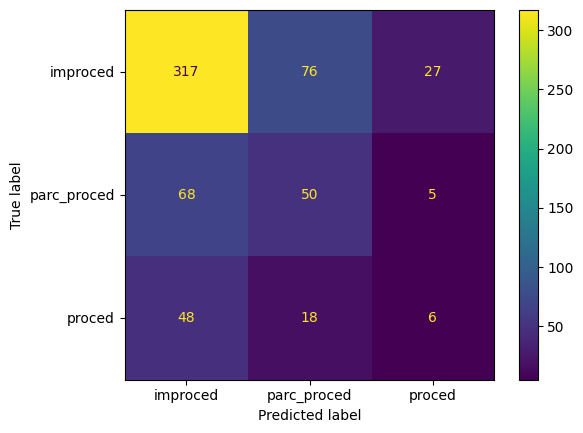

In [8]:
estimadores(searchCV_pipeline, X_test, y_test)

### GBC

In [9]:
modelo= GradientBoostingClassifier()

parametros = {
    'modelo__n_estimators': [100],
    'modelo__max_depth': [2, 6],
    'modelo__max_leaf_nodes': [10],
    'modelo__learning_rate': [0.05, 0.2]
    }

In [10]:
lista_filtro = ['n_processo', 'escopo', 'data_de_disponibilizacao', 'decisao',
                'morais_ped', 'morais_rec', 'materiais_ped', 'materiais_rec', 
                'classe', 'assunto', 'foro', 'vara', 'juiz', 'data_distribuicao', 
                'area', 'resumo_caso']


X = df_vet.drop(columns=lista_filtro)

y = df_vet["decisao"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=22)

num_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_prep, ['valor_acao']),
    ])


pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('modelo', modelo)
    ])

searchCV_pipeline = RandomizedSearchCV(
    pipeline,
    parametros,
    scoring='roc_auc_ovr',
    refit= True,
    cv=5,
    verbose= 2
)


sample_weight = compute_sample_weight('balanced', y_train)
searchCV_pipeline.fit(X_train, y_train, modelo__sample_weight=sample_weight)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


c:\Users\peper\OneDrive\Documentos\PIBIC\.venv\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


[CV] END modelo__learning_rate=0.05, modelo__max_depth=2, modelo__max_leaf_nodes=10, modelo__n_estimators=100; total time=   0.2s
[CV] END modelo__learning_rate=0.05, modelo__max_depth=2, modelo__max_leaf_nodes=10, modelo__n_estimators=100; total time=   0.2s
[CV] END modelo__learning_rate=0.05, modelo__max_depth=2, modelo__max_leaf_nodes=10, modelo__n_estimators=100; total time=   0.1s
[CV] END modelo__learning_rate=0.05, modelo__max_depth=2, modelo__max_leaf_nodes=10, modelo__n_estimators=100; total time=   0.1s
[CV] END modelo__learning_rate=0.05, modelo__max_depth=2, modelo__max_leaf_nodes=10, modelo__n_estimators=100; total time=   0.1s
[CV] END modelo__learning_rate=0.05, modelo__max_depth=6, modelo__max_leaf_nodes=10, modelo__n_estimators=100; total time=   0.2s
[CV] END modelo__learning_rate=0.05, modelo__max_depth=6, modelo__max_leaf_nodes=10, modelo__n_estimators=100; total time=   0.2s
[CV] END modelo__learning_rate=0.05, modelo__max_depth=6, modelo__max_leaf_nodes=10, model

,estimator,Pipeline(step...lassifier())])
,param_distributions,"{'modelo__learning_rate': [0.05, 0.2], 'modelo__max_depth': [2, 6], 'modelo__max_leaf_nodes': [10], 'modelo__n_estimators': [100]}"
,n_iter,10
,scoring,'roc_auc_ovr'
,n_jobs,None
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan



        Acurácia: 0.397
        Recall (weighted): 0.397
        F1-score (weighted): 0.446
        ROC AUC (ovr): 0.550
        
              precision    recall  f1-score   support

    improced       0.72      0.46      0.56       420
 parc_proced       0.19      0.25      0.22       123
      proced       0.10      0.26      0.15        72

    accuracy                           0.40       615
   macro avg       0.34      0.33      0.31       615
weighted avg       0.54      0.40      0.45       615



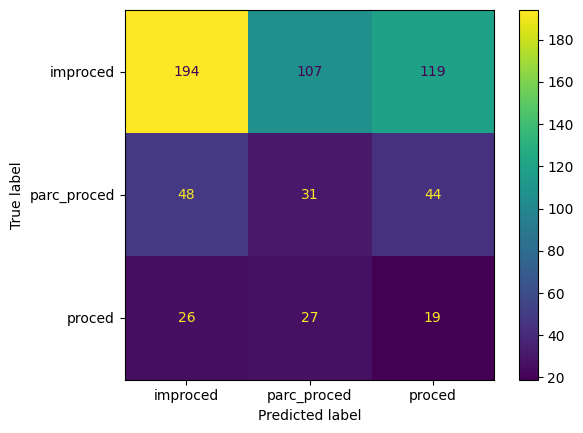

In [11]:
estimadores(searchCV_pipeline, X_test, y_test)